
# Project 1 — in PyPSA

The formulation using **PyPSA** workflow.

Main mapping:
- hourly balance -> `Bus` + `Load`
- renewable capacity and dispatch -> `Generator` with `p_nom_extendable=True` and `p_max_pu`
- thermal capacity and dispatch -> dispatchable `Generator`
- battery with fixed energy-to-power ratio -> `StorageUnit` with `max_hours`

Notes:
- The original Part A declared `K_battery` but did not use it. It is removed in the PyPSA Part A model.
- The original Part C defined `battery_opex` but did not include it in the objective. The conversion below preserves the original objective structure by default.

## Common data loading

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pypsa


def load_base_year_data():
    offshore_wind_cf = pd.read_csv("../data/averaged_offshore_wind_capacity_factor_denmark_hourly.csv", index_col=0)
    onshore_wind_cf = pd.read_csv("../data/averaged_onshore_wind_capacity_factor_denmark_hourly.csv", index_col=0)
    pv_cf = pd.read_csv("../data/averaged_pv_capacity_factor_denmark_hourly.csv", index_col=0)
    demand = pd.read_csv("../data/denmark_demand.csv", index_col=0)

    pv = pv_cf.rename(columns={"cf": "pv_cf"})
    onshore = onshore_wind_cf.rename(columns={"cf": "onshore_cf"})
    offshore = offshore_wind_cf.rename(columns={"cf": "offshore_cf"})

    work_df = pd.concat([pv, onshore, offshore, demand], axis=1)
    work_df.index = pd.to_datetime(
        "2015/" + work_df.index.astype(str),
        format="%Y/%d/%m %H:%M"
    )
    work_df = work_df.rename(columns={"demand": "demand_mw"})
    return work_df


work_df = load_base_year_data()
work_df.head()


,pv_cf,onshore_cf,offshore_cf,demand_mw
time,,,,
2015-01-01 00:00:00,0.0,0.419545,0.629273,3210.98
2015-01-01 01:00:00,0.0,0.407818,0.643364,3100.02
2015-01-01 02:00:00,0.0,0.396909,0.644636,2980.39
2015-01-01 03:00:00,0.0,0.395182,0.623364,2933.49
2015-01-01 04:00:00,0.0,0.386545,0.602273,2941.54


## Technology assumptions

In [2]:

# Technology lifetimes [years]
onshore_wind_lifetime = 30
offshore_wind_lifetime = 30
pv_lifetime = 35
ccgt_lifetime = 25
ocgt_lifetime = 25
biomass_chp_lifetime = 25
battery_lifetime = 17

# CAPEX [EUR/MW] except battery energy term handled separately
onshore_wind_capex = 1.16e6     
offshore_wind_capex = 2.5e6
pv_capex = 5e5
ccgt_capex = 9e5 
ocgt_capex = 6e5
biomass_chp_capex = 5e6 
battery_capex = 4.5e5  

# Annualised capital costs [EUR/MW/year] using CAPEX / lifetime
annualised_offshore_wind_capex = offshore_wind_capex / offshore_wind_lifetime
annualised_onshore_wind_capex = onshore_wind_capex / onshore_wind_lifetime
annualised_pv_capex = pv_capex / pv_lifetime
annualised_ccgt_capex = ccgt_capex / ccgt_lifetime
annualised_ocgt_capex = ocgt_capex / ocgt_lifetime
annualised_chp_capex = biomass_chp_capex / biomass_chp_lifetime
annualised_battery_inverter_capex = battery_capex / battery_lifetime

# Annual OPEX/FOM-like costs [EUR/MW/year]
offshore_wind_opex = 40_000
onshore_wind_opex = 17_000
pv_opex = 10_500
ccgt_opex = 30_500
ocgt_opex = 20_000
chp_opex = 150_000
battery_opex = 10_000   # kept for reference; original objective did not use it

# Battery energy cost [EUR/MWh/year]
annualised_battery_energy_capex = 0.5
battery_hours = 2
battery_inverter_efficiency = 0.96

# Efficiencies
ccgt_efficiency = 0.57
ocgt_efficiency = 0.40
chp_efficiency = 0.25

# Fuel/input prices [EUR/MWh_fuel]
gas_price = 30
chp_input_price = 25

# Marginal costs [EUR/MWh_e]
onshore_wind_marginal_cost = 4
offshore_wind_marginal_cost = 2
pv_marginal_cost = 0
ccgt_marginal_cost = 4.5 + gas_price / ccgt_efficiency
ocgt_marginal_cost = 4.5 + gas_price / ocgt_efficiency
chp_marginal_cost = 15 + chp_input_price / chp_efficiency

tech_costs = pd.DataFrame(
    {
        "capital_cost_eur_per_mw_year": {
            "pv": annualised_pv_capex + pv_opex,
            "onshore": annualised_onshore_wind_capex + onshore_wind_opex,
            "offshore": annualised_offshore_wind_capex + offshore_wind_opex,
            "ccgt": annualised_ccgt_capex + ccgt_opex,
            "ocgt": annualised_ocgt_capex + ocgt_opex,
            "chp": annualised_chp_capex + chp_opex,
        },
        "marginal_cost_eur_per_mwh": {
            "pv": pv_marginal_cost,
            "onshore": onshore_wind_marginal_cost,
            "offshore": offshore_wind_marginal_cost,
            "ccgt": ccgt_marginal_cost,
            "ocgt": ocgt_marginal_cost,
            "chp": chp_marginal_cost,
        },
    }
)

tech_costs


,capital_cost_eur_per_mw_year,marginal_cost_eur_per_mwh
pv,24785.714286,0.000000
onshore,55666.666667,4.000000
offshore,123333.333333,2.000000
ccgt,66500.000000,57.131579
ocgt,44000.000000,79.500000
chp,350000.000000,115.000000


## Part A — PyPSA capacity expansion without storage

In [3]:


def build_part_a_network(work_df: pd.DataFrame) -> pypsa.Network:
    n = pypsa.Network()
    n.set_snapshots(work_df.index)

    n.add("Bus", "DK")
    n.add("Load", "demand", bus="DK", p_set=work_df["demand_mw"])

    n.add(
        "Generator", "pv",
        bus="DK",
        carrier="pv",
        p_nom_extendable=True,
        p_max_pu=work_df["pv_cf"],
        capital_cost=annualised_pv_capex + pv_opex,
        marginal_cost=pv_marginal_cost,
    )

    n.add(
        "Generator", "onshore",
        bus="DK",
        carrier="onshore",
        p_nom_extendable=True,
        p_max_pu=work_df["onshore_cf"],
        capital_cost=annualised_onshore_wind_capex + onshore_wind_opex,
        marginal_cost=onshore_wind_marginal_cost,
    )

    n.add(
        "Generator", "offshore",
        bus="DK",
        carrier="offshore",
        p_nom_extendable=True,
        p_max_pu=work_df["offshore_cf"],
        capital_cost=annualised_offshore_wind_capex + offshore_wind_opex,
        marginal_cost=offshore_wind_marginal_cost,
    )

    for name, cap_cost, marg_cost in [
        ("ccgt", annualised_ccgt_capex + ccgt_opex, ccgt_marginal_cost),
        ("ocgt", annualised_ocgt_capex + ocgt_opex, ocgt_marginal_cost),
        ("chp", annualised_chp_capex + chp_opex, chp_marginal_cost),
    ]:
        n.add(
            "Generator", name,
            bus="DK",
            carrier=name,
            p_nom_extendable=True,
            capital_cost=cap_cost,
            marginal_cost=marg_cost,
        )

    return n

n_a = build_part_a_network(work_df)
status_a, condition_a = n_a.optimize(solver_name="highs")
print("Part A status:", status_a, condition_a)


Index(['DK'], dtype='str', name='name')
Index(['pv', 'onshore', 'offshore', 'ccgt', 'ocgt', 'chp'], dtype='str', name='name')


TypeError: Invalid array type: <class 'pandas.arrays.ArrowStringArray'>

In [7]:

# Part A results

gen_order = ["pv", "onshore", "offshore", "ccgt", "ocgt", "chp"]

capacity_a = n_a.generators.p_nom_opt.reindex(gen_order).rename("capacity_MW")
annual_generation_a = n_a.generators_t.p[gen_order].sum().rename("annual_generation_MWh")

summary_a = pd.concat([capacity_a, annual_generation_a], axis=1)
summary_a["fleet_capacity_factor"] = (
    summary_a["annual_generation_MWh"] / (summary_a["capacity_MW"] * 8760)
).replace([float("inf")], 0).fillna(0)
summary_a["generation_share"] = (
    summary_a["annual_generation_MWh"] / summary_a["annual_generation_MWh"].sum()
)

summary_a


KeyError: "None of [Index(['pv', 'onshore', 'offshore', 'ccgt', 'ocgt', 'chp'], dtype='str', name='name')] are in the [columns]"

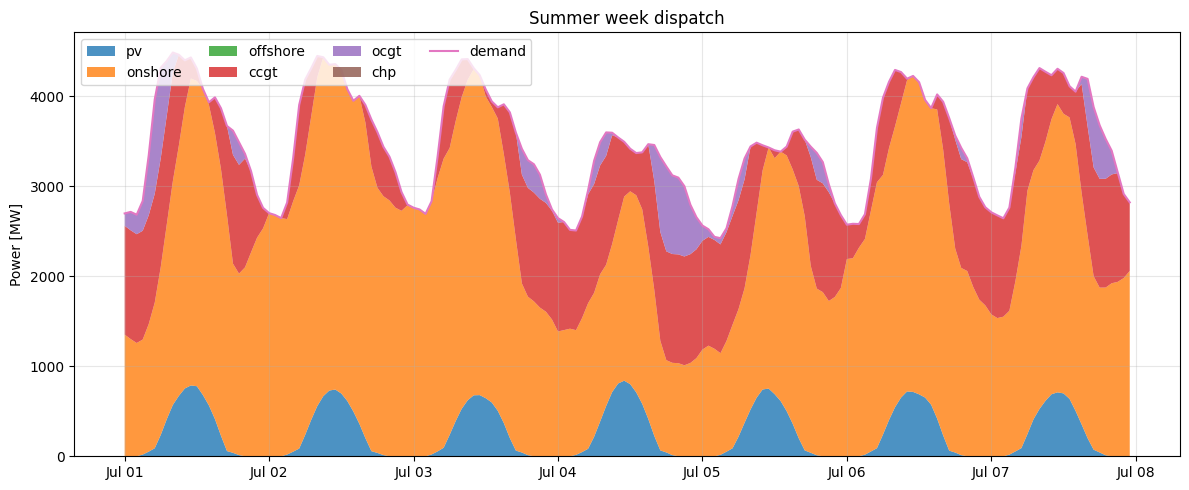

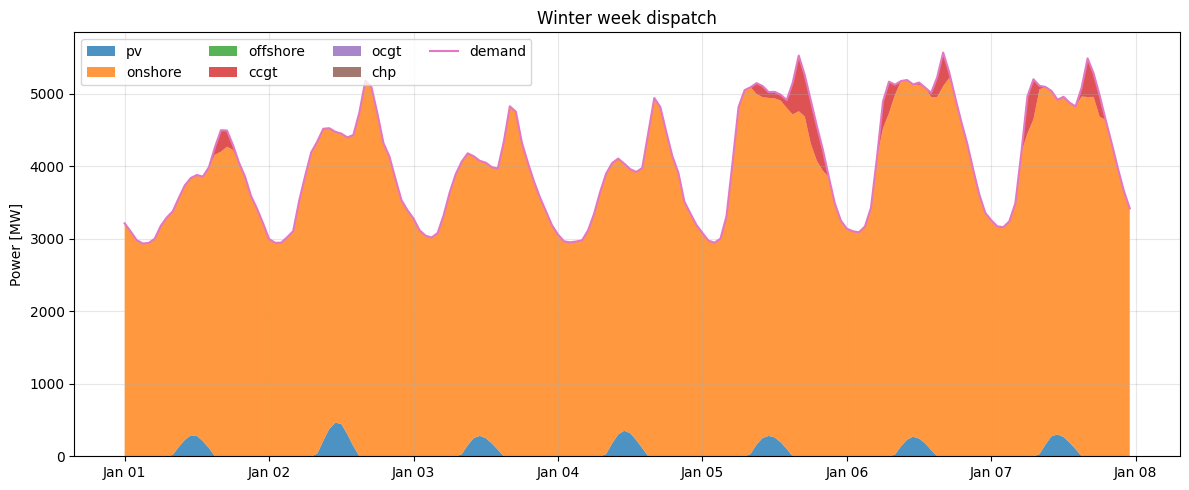

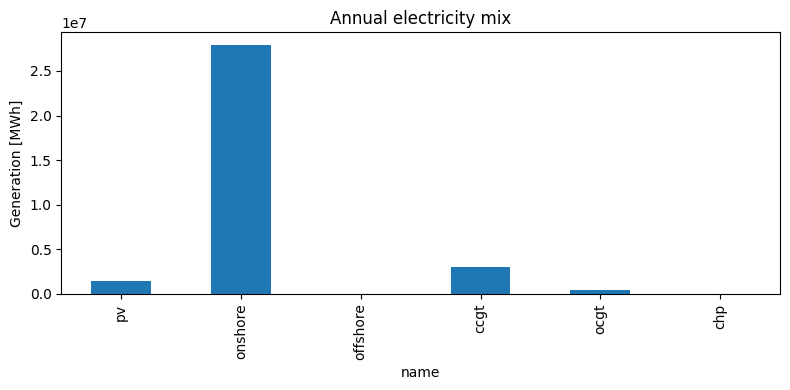

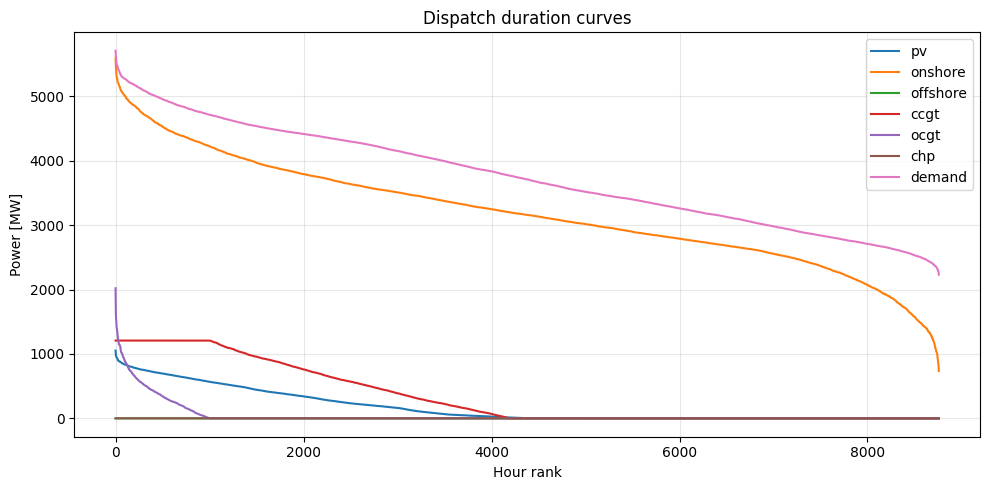

In [5]:

# Part A dispatch plots

dispatch_a = n_a.generators_t.p[gen_order].copy()
dispatch_a["demand"] = work_df["demand_mw"]

for title, start, end in [
    ("Summer week dispatch", "2015-07-01", "2015-07-07 23:00"),
    ("Winter week dispatch", "2015-01-01", "2015-01-07 23:00"),
]:
    week = dispatch_a.loc[start:end]
    x = week.index

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.stackplot(
        x,
        week["pv"],
        week["onshore"],
        week["offshore"],
        week["ccgt"],
        week["ocgt"],
        week["chp"],
        labels=["pv", "onshore", "offshore", "ccgt", "ocgt", "chp"],
        alpha=0.8,
    )
    ax.plot(x, week["demand"], linewidth=1.5, label="demand")
    ax.set_title(title)
    ax.set_ylabel("Power [MW]")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.legend(loc="upper left", ncol=4)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

annual_generation_a.plot(kind="bar", figsize=(8, 4), title="Annual electricity mix")
plt.ylabel("Generation [MWh]")
plt.tight_layout()
plt.show()


duration_a = pd.DataFrame({col: dispatch_a[col].sort_values(ascending=False).values for col in gen_order + ["demand"]})
fig, ax = plt.subplots(figsize=(10, 5))
duration_a.plot(ax=ax)
ax.set_title("Dispatch duration curves")
ax.set_xlabel("Hour rank")
ax.set_ylabel("Power [MW]")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Part B — reuse the PyPSA builder for weather-year sensitivity

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load one-country hourly series
# --------------------------------------------------
def load_country_series(path, value_name, country="DNK", sep=";"):
    df = pd.read_csv(path, sep=sep)
    df["utc_time"] = pd.to_datetime(df["utc_time"], utc=True)
    df = df.set_index("utc_time")
    df = df[[country]].rename(columns={country: value_name})
    return df

# --------------------------------------------------
# Remove leap day for comparability
# --------------------------------------------------
def drop_feb29(df):
    return df.loc[~((df.index.month == 2) & (df.index.day == 29))].copy()

# --------------------------------------------------
# Load data
# --------------------------------------------------
demand = load_country_series("data/electricity_demand.csv", "demand_mw")

onshore_cf = load_country_series("data/onshore_wind_capacity_factor_raw.csv", "onshore_cf")
offshore_cf = load_country_series("data/offshore_wind_capacity_factor_raw.csv", "offshore_cf")
pv_cf       = load_country_series("data/pv_capacity_factor_raw.csv", "pv_cf")

# Fixed reference demand for all weather years
demand_ref = drop_feb29(demand)

# Merge renewable profiles
weather_all = onshore_cf.join(offshore_cf, how="inner").join(pv_cf, how="inner")
weather_all = drop_feb29(weather_all)

In [7]:
def build_weather_year_dict(weather_all, demand_ref):
    weather_years = {}

    for year, df_year in weather_all.groupby(weather_all.index.year):
        df_year = drop_feb29(df_year)

        # Skip incomplete years
        if len(df_year) != len(demand_ref):
            print(f"Skipping {year}: expected {len(demand_ref)} hours, got {len(df_year)}")
            continue

        # Reindex weather year onto fixed 2015 demand timestamps
        df_year = df_year.copy()
        df_year.index = demand_ref.index

        work_df_year = df_year.join(demand_ref, how="inner")
        weather_years[year] = work_df_year

    return weather_years

weather_years = build_weather_year_dict(weather_all, demand_ref)

print(f"Usable weather years: {min(weather_years)}–{max(weather_years)}")
print(f"Number of weather years: {len(weather_years)}")
display(next(iter(weather_years.values())).head())

Usable weather years: 1979–2017
Number of weather years: 39


,onshore_cf,offshore_cf,pv_cf,demand_mw
utc_time,,,,
2015-01-01 00:00:00+00:00,0.712,0.986,0.0,3210.98
2015-01-01 01:00:00+00:00,0.704,0.985,0.0,3100.02
2015-01-01 02:00:00+00:00,0.673,0.978,0.0,2980.39
2015-01-01 03:00:00+00:00,0.635,0.968,0.0,2933.49
2015-01-01 04:00:00+00:00,0.604,0.957,0.0,2941.54


In [9]:
capacity_results = {}
generation_results = {}
cost_results = {}

for year, work_df_year in weather_years.items():
    print(f"Solving {year}...")

    # PyPSA requires timezone-naive snapshots
    work_df_year = work_df_year.copy()
    work_df_year.index = pd.DatetimeIndex(work_df_year.index).tz_localize(None)

    n = build_part_a_network(work_df_year)
    status, condition = n.optimize(solver_name="highs")

    if status != "ok" or condition != "optimal":
        print(f"  Failed: {status}, {condition}")
        continue

    capacities = (
        n.generators[["carrier", "p_nom_opt"]]
        .groupby("carrier")["p_nom_opt"]
        .sum()
    )
    capacity_results[year] = capacities

    generation = (
        n.generators_t.p.sum()
        .rename("generation_mwh")
        .to_frame()
        .join(n.generators["carrier"])
        .groupby("carrier")["generation_mwh"]
        .sum()
    )
    generation_results[year] = generation

    fixed_cost = n.statistics.capex().sum()
    opex = n.statistics.opex().sum()

    cost_results[year] = {
        "fixed_annual_cost_eur_per_year": fixed_cost,
        "opex_eur_per_year": opex,
        "total_annual_cost_eur_per_year": fixed_cost + opex,
    }

capacities_df = pd.DataFrame(capacity_results).T.sort_index()
generation_df = pd.DataFrame(generation_results).T.sort_index()
cost_df = pd.DataFrame(cost_results).T.sort_index()

capacity_stats = pd.DataFrame({
    "mean_mw": capacities_df.mean(),
    "std_mw": capacities_df.std(),
    "min_mw": capacities_df.min(),
    "max_mw": capacities_df.max(),
    "cv": capacities_df.std() / capacities_df.mean(),
}).sort_values("mean_mw", ascending=False)

display(capacities_df)
display(capacity_stats)
display(cost_df)

C:\Users\Study\AppData\Local\Temp\ipykernel_15656\1828912168.py:13: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['DK'], dtype='str', name='name')
Index(['pv', 'onshore', 'offshore', 'ccgt', 'ocgt', 'chp'], dtype='str', name='name')


Solving 1979...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 240.15it/s]
INFO:linopy.io: Writing time: 0.08s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52566 primals, 113886 duals
Objective: 1.63e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.
C:\Users\Study\AppData\Local\Temp\ipykernel_15656\1828912168.py:13: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['DK'], dtype='str', name='name')
Index(['pv', 'onshore', 'offshore', 'ccgt', 'ocgt', 'chp'],

Solving 1980...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 257.99it/s]
INFO:linopy.io: Writing time: 0.07s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52566 primals, 113886 duals
Objective: 1.72e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.
C:\Users\Study\AppData\Local\Temp\ipykernel_15656\1828912168.py:13: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['DK'], dtype='str', name='name')
Index(['pv', 'onshore', 'offshore', 'ccgt', 'ocgt', 'chp'],

...

Solving 2017...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 246.33it/s]
INFO:linopy.io: Writing time: 0.08s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52566 primals, 113886 duals
Objective: 1.69e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


carrier,ccgt,chp,ocgt,offshore,onshore,pv
1979,2985.237262,0.0,2174.185685,0.0,8408.898810,5691.505903
1980,3145.240164,0.0,2174.203196,0.0,7923.332575,6635.364892
1981,3042.080787,0.0,2307.960000,0.0,7903.968531,6892.162627
1982,3173.344464,0.0,2121.478929,0.0,7741.964286,6898.739863
1983,2948.345764,0.0,2155.515903,0.0,7934.097222,6060.331330
1984,3055.520651,0.0,2093.727383,0.0,8323.196544,5799.570235
1985,3187.478637,0.0,2134.281090,0.0,8225.570698,6230.991789
1986,2948.622335,0.0,2401.933849,0.0,8305.318027,6043.286164
1987,3208.329875,0.0,2184.391875,0.0,7914.875000,6558.842002
1988,2945.262657,0.0,2312.197915,0.0,8335.904751,5631.622605


,mean_mw,std_mw,min_mw,max_mw,cv
carrier,,,,,
onshore,8104.196157,291.398201,7537.552987,8813.746109,0.035956
pv,6231.663192,470.529708,4778.914494,7271.302526,0.075506
ccgt,3036.090982,93.067236,2814.337001,3208.329875,0.030654
ocgt,2299.214382,149.530602,2048.746695,2626.601521,0.065036
chp,0.000000,0.000000,0.000000,0.000000,NaN
offshore,0.000000,0.000000,0.000000,0.000000,NaN


,fixed_annual_cost_eur_per_year,opex_eur_per_year,total_annual_cost_eur_per_year
1979,9.033459e+08,7.268455e+08,1.630191e+09
1980,9.103512e+08,8.104978e+08,1.720849e+09
1981,9.146634e+08,7.745490e+08,1.689212e+09
1982,9.063320e+08,8.121324e+08,1.718464e+09
1983,8.827821e+08,7.195975e+08,1.602380e+09
1984,9.023872e+08,7.399215e+08,1.642309e+09
1985,9.182054e+08,8.047567e+08,1.722962e+09
1986,9.138850e+08,7.003389e+08,1.614224e+09
1987,9.126275e+08,8.216106e+08,1.734238e+09
1988,9.012125e+08,7.256390e+08,1.626852e+09



=== Optimal capacities by weather year [MW] ===


carrier,pv,onshore,offshore,ccgt,ocgt,chp
1979,5691.51,8408.90,0.0,2985.24,2174.19,0.0
1980,6635.36,7923.33,0.0,3145.24,2174.20,0.0
1981,6892.16,7903.97,0.0,3042.08,2307.96,0.0
1982,6898.74,7741.96,0.0,3173.34,2121.48,0.0
1983,6060.33,7934.10,0.0,2948.35,2155.52,0.0
1984,5799.57,8323.20,0.0,3055.52,2093.73,0.0
1985,6230.99,8225.57,0.0,3187.48,2134.28,0.0
1986,6043.29,8305.32,0.0,2948.62,2401.93,0.0
1987,6558.84,7914.88,0.0,3208.33,2184.39,0.0
1988,5631.62,8335.90,0.0,2945.26,2312.20,0.0



=== Capacity statistics [MW] ===


,mean_mw,std_mw,min_mw,max_mw,cv
carrier,,,,,
pv,6231.66,470.53,4778.91,7271.30,0.08
onshore,8104.20,291.40,7537.55,8813.75,0.04
offshore,0.00,0.00,0.00,0.00,NaN
ccgt,3036.09,93.07,2814.34,3208.33,0.03
ocgt,2299.21,149.53,2048.75,2626.60,0.07
chp,0.00,0.00,0.00,0.00,NaN



=== Annual generation by weather year [MWh] ===


...

,fixed_annual_cost_eur_per_year,opex_eur_per_year,total_annual_cost_eur_per_year
1979,9.033459e+08,7.268455e+08,1.630191e+09
1980,9.103512e+08,8.104978e+08,1.720849e+09
1981,9.146634e+08,7.745490e+08,1.689212e+09
1982,9.063320e+08,8.121324e+08,1.718464e+09
1983,8.827821e+08,7.195975e+08,1.602380e+09
1984,9.023872e+08,7.399215e+08,1.642309e+09
1985,9.182054e+08,8.047567e+08,1.722962e+09
1986,9.138850e+08,7.003389e+08,1.614224e+09
1987,9.126275e+08,8.216106e+08,1.734238e+09
1988,9.012125e+08,7.256390e+08,1.626852e+09



=== System indicators by weather year ===


,total_generation_mwh,thermal_generation_mwh,vre_generation_mwh,thermal_share_pct,vre_share_pct,total_annual_cost_eur_per_year,fixed_annual_cost_eur_per_year,opex_eur_per_year
1979,32813939.13,11312748.27,21501190.86,34.48,65.52,1.630191e+09,9.033459e+08,7.268455e+08
1980,32813939.13,12938698.47,19875240.66,39.43,60.57,1.720849e+09,9.103512e+08,8.104978e+08
1981,32813939.13,12316199.66,20497739.47,37.53,62.47,1.689212e+09,9.146634e+08,7.745490e+08
1982,32813939.13,13039856.58,19774082.55,39.74,60.26,1.718464e+09,9.063320e+08,8.121324e+08
1983,32813939.13,11200163.72,21613775.41,34.13,65.87,1.602380e+09,8.827821e+08,7.195975e+08
1984,32813939.13,11586425.97,21227513.16,35.31,64.69,1.642309e+09,9.023872e+08,7.399215e+08
1985,32813939.13,12804583.33,20009355.80,39.02,60.98,1.722962e+09,9.182054e+08,8.047567e+08
1986,32813939.13,10851841.50,21962097.63,33.07,66.93,1.614224e+09,9.138850e+08,7.003389e+08
1987,32813939.13,13159047.96,19654891.17,40.10,59.90,1.734238e+09,9.126275e+08,8.216106e+08
1988,32813939.13,11271829.11,21542110.02,34.35,65.65,1.626852e+09,9.012125e+08,7.256390e+08



=== Compact interpretation table ===


,capacity_mean_mw,capacity_std_mw,capacity_cv,generation_mean_share_pct,generation_share_std_pct
carrier,,,,,
pv,6231.663,470.530,0.076,16.936,1.772
onshore,8104.196,291.398,0.036,46.747,3.783
offshore,0.000,0.000,NaN,0.000,0.000
ccgt,3036.091,93.067,0.031,34.479,2.368
ocgt,2299.214,149.531,0.065,1.838,0.092
chp,0.000,0.000,NaN,0.000,0.000


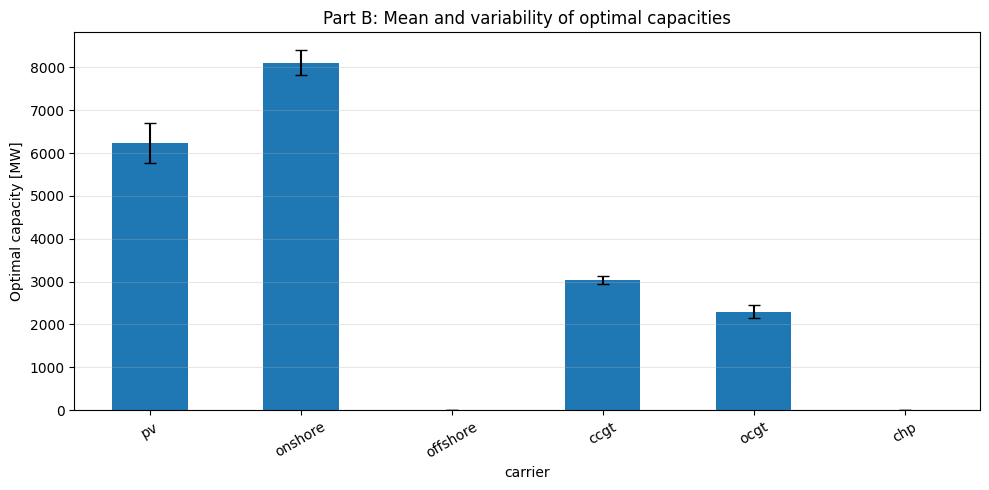

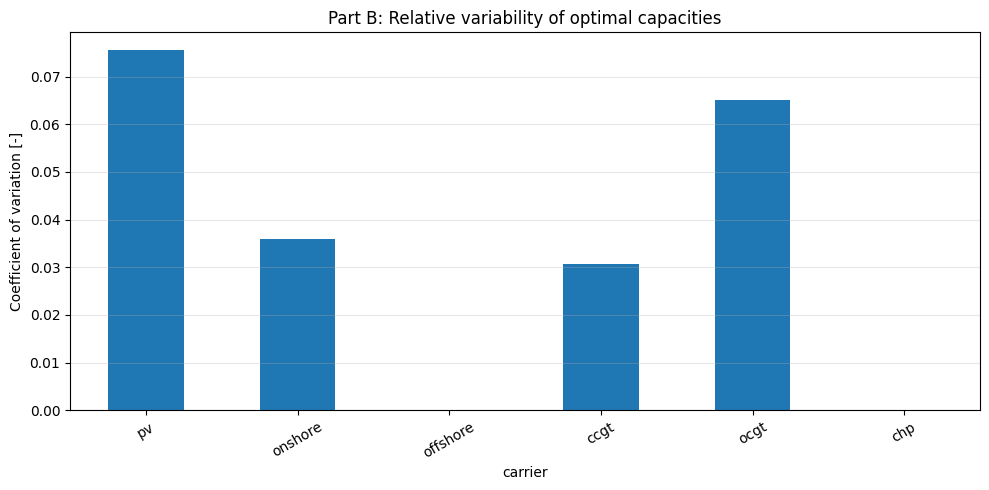

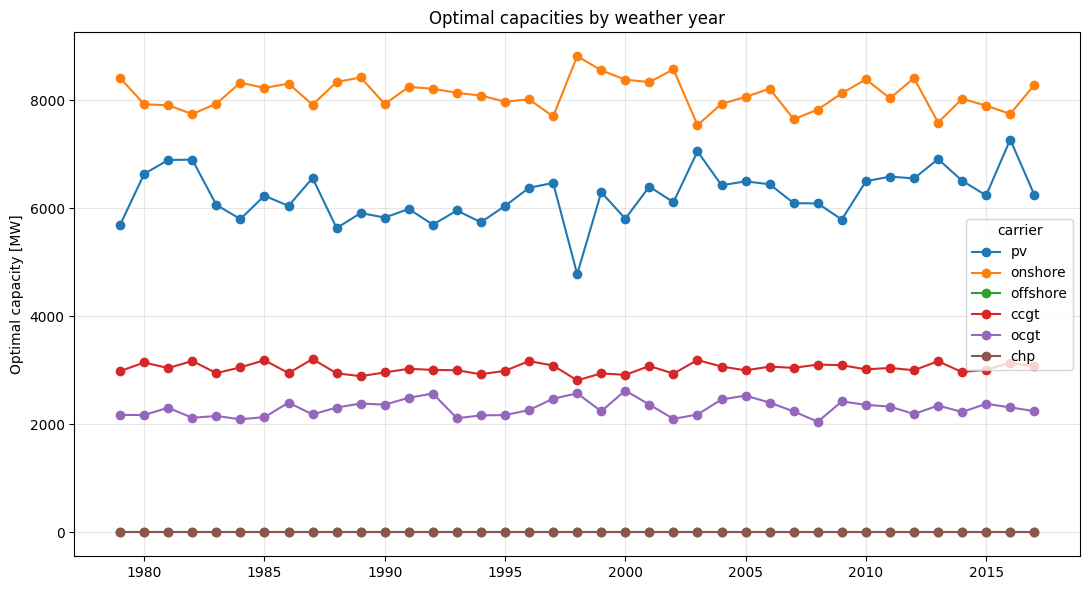

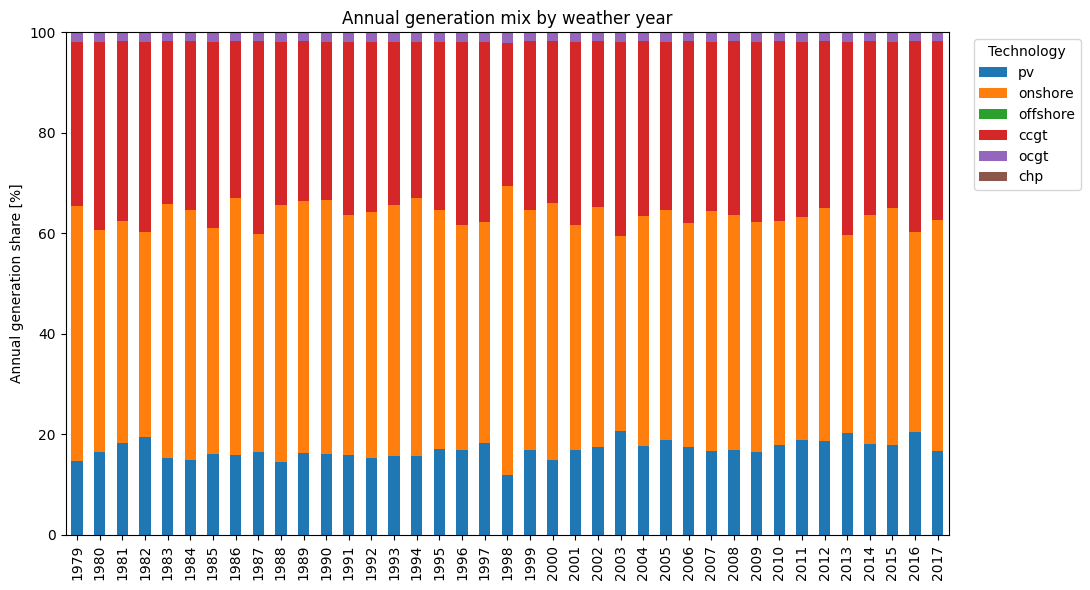

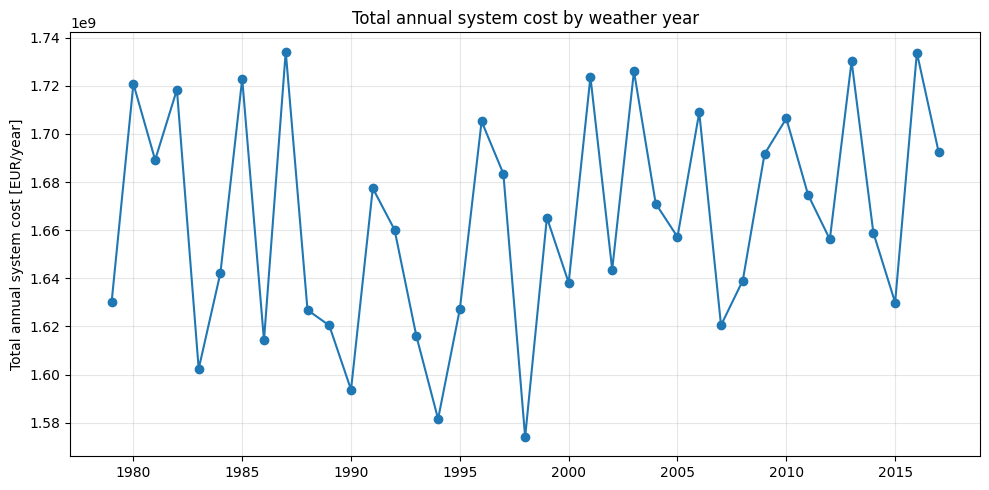

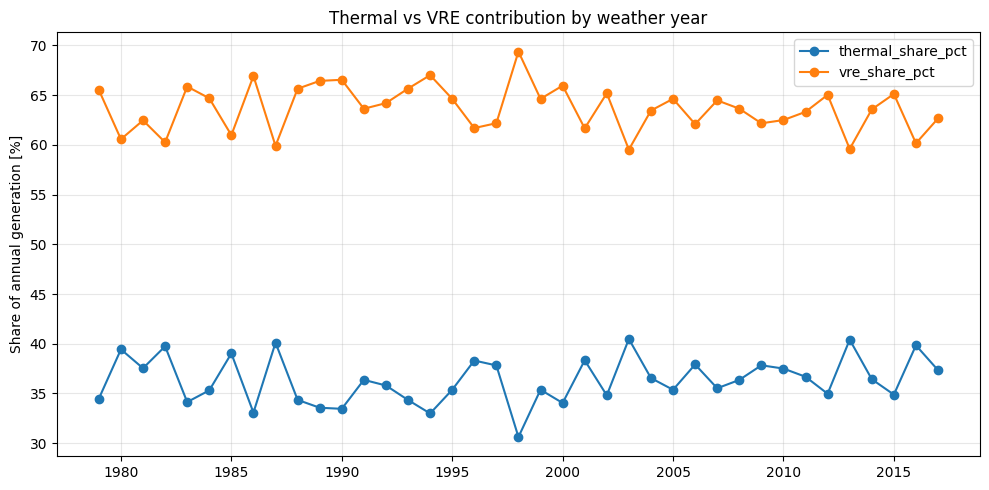


=== Automatic Part B highlights ===
Most weather-sensitive capacity (highest CV): pv (CV = 0.076)
Least weather-sensitive capacity (lowest CV): ccgt (CV = 0.031)
Highest thermal reliance year: 2003 (40.47%)
Lowest thermal reliance year: 1998 (30.62%)
Highest-cost year: 1987 (1734238041.66 EUR/year)
Lowest-cost year: 1998 (1574055605.79 EUR/year)

Part B shows that the optimal capacity mix varies across weather years even when demand and techno-economic assumptions are fixed.
On average, the largest installed capacities are onshore (8104.2 MW),
pv (6231.7 MW), and ccgt (3036.1 MW).
The most weather-sensitive technology in relative terms is pv with a coefficient of variation of 0.076,
while the least weather-sensitive is chp with a coefficient of variation of nan.
Across the analysed years, thermal generation ranges from
30.62% to 40.47% of annual generation,
indicating how interannual renewable resource variability changes the need for dispatchable backup.



In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PART B — RESULT ANALYSIS
# Assumes these already exist:
#   capacities_df, generation_df, cost_df
# ============================================================

# -----------------------------
# 1) Consistent technology order
# -----------------------------
tech_order = ["pv", "onshore", "offshore", "ccgt", "ocgt", "chp"]

capacities_df = capacities_df.copy().reindex(columns=tech_order)
generation_df = generation_df.copy().reindex(columns=tech_order)

# keep only expected cost columns if present
expected_cost_cols = [
    "fixed_annual_cost_eur_per_year",
    "opex_eur_per_year",
    "total_annual_cost_eur_per_year",
]
cost_cols_present = [c for c in expected_cost_cols if c in cost_df.columns]
cost_df = cost_df.copy()[cost_cols_present]

# -----------------------------
# 2) Summary statistics
# -----------------------------
capacity_stats = pd.DataFrame({
    "mean_mw": capacities_df.mean(),
    "std_mw": capacities_df.std(),
    "min_mw": capacities_df.min(),
    "max_mw": capacities_df.max(),
    "cv": capacities_df.std() / capacities_df.mean(),
}).reindex(tech_order)

generation_stats = pd.DataFrame({
    "mean_mwh": generation_df.mean(),
    "std_mwh": generation_df.std(),
    "min_mwh": generation_df.min(),
    "max_mwh": generation_df.max(),
    "cv": generation_df.std() / generation_df.mean(),
}).reindex(tech_order)

# annual generation shares by year
generation_share_df = generation_df.div(generation_df.sum(axis=1), axis=0) * 100

generation_share_stats = pd.DataFrame({
    "mean_share_pct": generation_share_df.mean(),
    "std_share_pct": generation_share_df.std(),
    "min_share_pct": generation_share_df.min(),
    "max_share_pct": generation_share_df.max(),
}).reindex(tech_order)

# approximate annual capacity factor by year
# generation [MWh] / (capacity [MW] * 8760 h)
capacity_factor_df = generation_df / (capacities_df * 8760)
capacity_factor_df = capacity_factor_df.replace([np.inf, -np.inf], np.nan)
capacity_factor_stats = pd.DataFrame({
    "mean_cf": capacity_factor_df.mean(),
    "std_cf": capacity_factor_df.std(),
    "min_cf": capacity_factor_df.min(),
    "max_cf": capacity_factor_df.max(),
}).reindex(tech_order)

# -----------------------------
# 3) System-level indicators
# -----------------------------
thermal_techs = [t for t in ["ccgt", "ocgt", "chp"] if t in generation_df.columns]
vre_techs = [t for t in ["pv", "onshore", "offshore"] if t in generation_df.columns]

system_indicators = pd.DataFrame(index=generation_df.index)

system_indicators["total_generation_mwh"] = generation_df.sum(axis=1)
system_indicators["thermal_generation_mwh"] = generation_df[thermal_techs].sum(axis=1) if thermal_techs else 0.0
system_indicators["vre_generation_mwh"] = generation_df[vre_techs].sum(axis=1) if vre_techs else 0.0

system_indicators["thermal_share_pct"] = (
    100 * system_indicators["thermal_generation_mwh"] / system_indicators["total_generation_mwh"]
)
system_indicators["vre_share_pct"] = (
    100 * system_indicators["vre_generation_mwh"] / system_indicators["total_generation_mwh"]
)

if "total_annual_cost_eur_per_year" in cost_df.columns:
    system_indicators = system_indicators.join(cost_df["total_annual_cost_eur_per_year"])

if "fixed_annual_cost_eur_per_year" in cost_df.columns:
    system_indicators = system_indicators.join(cost_df["fixed_annual_cost_eur_per_year"])

if "opex_eur_per_year" in cost_df.columns:
    system_indicators = system_indicators.join(cost_df["opex_eur_per_year"])

# identify notable years
highest_cost_year = (
    system_indicators["total_annual_cost_eur_per_year"].idxmax()
    if "total_annual_cost_eur_per_year" in system_indicators.columns else None
)
lowest_cost_year = (
    system_indicators["total_annual_cost_eur_per_year"].idxmin()
    if "total_annual_cost_eur_per_year" in system_indicators.columns else None
)

highest_thermal_year = system_indicators["thermal_share_pct"].idxmax()
lowest_thermal_year = system_indicators["thermal_share_pct"].idxmin()

# -----------------------------
# 4) Report-ready tables
# -----------------------------
print("\n=== Optimal capacities by weather year [MW] ===")
display(capacities_df.round(2))

print("\n=== Capacity statistics [MW] ===")
display(capacity_stats.round(2))

print("\n=== Annual generation by weather year [MWh] ===")
display(generation_df.round(2))

print("\n=== Generation statistics [MWh] ===")
display(generation_stats.round(2))

print("\n=== Mean generation share across weather years [%] ===")
display(generation_share_stats.round(2))

print("\n=== Approximate annual capacity factors [-] ===")
display(capacity_factor_stats.round(3))

print("\n=== Annual system cost summary ===")
display(cost_df.round(2))

print("\n=== System indicators by weather year ===")
display(system_indicators.round(2))

# compact interpretation table
interpretation_table = pd.DataFrame({
    "capacity_mean_mw": capacity_stats["mean_mw"],
    "capacity_std_mw": capacity_stats["std_mw"],
    "capacity_cv": capacity_stats["cv"],
    "generation_mean_share_pct": generation_share_stats["mean_share_pct"],
    "generation_share_std_pct": generation_share_stats["std_share_pct"],
}).reindex(tech_order)

print("\n=== Compact interpretation table ===")
display(interpretation_table.round(3))

# -----------------------------
# 5) Plot: mean ± std of optimal capacities
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))
capacity_stats["mean_mw"].plot(
    kind="bar",
    yerr=capacity_stats["std_mw"],
    capsize=4,
    ax=ax
)
ax.set_ylabel("Optimal capacity [MW]")
ax.set_title("Part B: Mean and variability of optimal capacities")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# -----------------------------
# 6) Plot: capacity coefficient of variation
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))
capacity_stats["cv"].plot(kind="bar", ax=ax)
ax.set_ylabel("Coefficient of variation [-]")
ax.set_title("Part B: Relative variability of optimal capacities")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# -----------------------------
# 7) Plot: optimal capacities by weather year
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 6))
capacities_df.plot(marker="o", ax=ax)
ax.set_ylabel("Optimal capacity [MW]")
ax.set_title("Optimal capacities by weather year")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 8) Plot: annual generation shares by weather year
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 6))
generation_share_df[tech_order].plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("Annual generation share [%]")
ax.set_title("Annual generation mix by weather year")
ax.legend(title="Technology", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# -----------------------------
# 9) Plot: system cost by weather year
# -----------------------------
if "total_annual_cost_eur_per_year" in cost_df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    cost_df["total_annual_cost_eur_per_year"].plot(marker="o", ax=ax)
    ax.set_ylabel("Total annual system cost [EUR/year]")
    ax.set_title("Total annual system cost by weather year")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 10) Plot: thermal and VRE shares by weather year
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))
system_indicators[["thermal_share_pct", "vre_share_pct"]].plot(marker="o", ax=ax)
ax.set_ylabel("Share of annual generation [%]")
ax.set_title("Thermal vs VRE contribution by weather year")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 11) Print key findings automatically
# -----------------------------
print("\n=== Automatic Part B highlights ===")
print(f"Most weather-sensitive capacity (highest CV): {capacity_stats['cv'].idxmax()} "
      f"(CV = {capacity_stats['cv'].max():.3f})")
print(f"Least weather-sensitive capacity (lowest CV): {capacity_stats['cv'].idxmin()} "
      f"(CV = {capacity_stats['cv'].min():.3f})")

print(f"Highest thermal reliance year: {highest_thermal_year} "
      f"({system_indicators.loc[highest_thermal_year, 'thermal_share_pct']:.2f}%)")
print(f"Lowest thermal reliance year: {lowest_thermal_year} "
      f"({system_indicators.loc[lowest_thermal_year, 'thermal_share_pct']:.2f}%)")

if highest_cost_year is not None and lowest_cost_year is not None:
    print(f"Highest-cost year: {highest_cost_year} "
          f"({system_indicators.loc[highest_cost_year, 'total_annual_cost_eur_per_year']:.2f} EUR/year)")
    print(f"Lowest-cost year: {lowest_cost_year} "
          f"({system_indicators.loc[lowest_cost_year, 'total_annual_cost_eur_per_year']:.2f} EUR/year)")

# -----------------------------
# 12) Report-friendly paragraph generator
# -----------------------------
top_cv = capacity_stats["cv"].sort_values(ascending=False)
top_mean = capacity_stats["mean_mw"].sort_values(ascending=False)

report_text = f"""
Part B shows that the optimal capacity mix varies across weather years even when demand and techno-economic assumptions are fixed.
On average, the largest installed capacities are {top_mean.index[0]} ({top_mean.iloc[0]:.1f} MW),
{top_mean.index[1]} ({top_mean.iloc[1]:.1f} MW), and {top_mean.index[2]} ({top_mean.iloc[2]:.1f} MW).
The most weather-sensitive technology in relative terms is {top_cv.index[0]} with a coefficient of variation of {top_cv.iloc[0]:.3f},
while the least weather-sensitive is {top_cv.index[-1]} with a coefficient of variation of {top_cv.iloc[-1]:.3f}.
Across the analysed years, thermal generation ranges from
{system_indicators['thermal_share_pct'].min():.2f}% to {system_indicators['thermal_share_pct'].max():.2f}% of annual generation,
indicating how interannual renewable resource variability changes the need for dispatchable backup.
"""
print(report_text)

## Part C — PyPSA capacity expansion with battery storage

In [28]:


def build_part_c_network(work_df: pd.DataFrame, include_battery_opex: bool = False) -> pypsa.Network:
    n = build_part_a_network(work_df)

    battery_capital_cost = (
        annualised_battery_inverter_capex
        + battery_hours * annualised_battery_energy_capex
    )

    if include_battery_opex:
        battery_capital_cost += battery_opex

    n.add(
        "StorageUnit", "battery",
        bus="DK",
        carrier="battery",
        p_nom_extendable=True,
        max_hours=battery_hours,
        efficiency_store=battery_inverter_efficiency,
        efficiency_dispatch=battery_inverter_efficiency,
        cyclic_state_of_charge=True,
        capital_cost=battery_capital_cost,
        marginal_cost=0.0,
    )

    return n


n_c = build_part_c_network(work_df, include_battery_opex=False)
status_c, condition_c = n_c.optimize(solver_name="highs")
print("Part C status:", status_c, condition_c)


C:\Users\Study\AppData\Local\Temp\ipykernel_15656\677079919.py:29: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['DK'], dtype='str', name='name')
Index(['pv', 'onshore', 'offshore', 'ccgt', 'ocgt', 'chp'], dtype='str', name='name')
Index(['battery'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 355.57it/s]
INFO:linopy.io: Writing time: 0.13s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 78847 primals, 175207 duals
Objective: 1.26e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generato

Part C status: ok optimal


In [29]:

# Part C results

gen_order = ["pv", "onshore", "offshore", "ccgt", "ocgt", "chp"]
storage_name = "battery"

capacity_c = n_c.generators.p_nom_opt.reindex(gen_order).rename("capacity_MW")
capacity_c.loc[storage_name] = n_c.storage_units.at[storage_name, "p_nom_opt"]

annual_generation_c = n_c.generators_t.p[gen_order].sum().rename("annual_generation_MWh")
storage_dispatch = n_c.storage_units_t.p[storage_name]
annual_generation_c.loc[storage_name] = storage_dispatch.clip(lower=0).sum()

summary_c = pd.concat([capacity_c, annual_generation_c], axis=1)
summary_c["fleet_capacity_factor"] = (
    summary_c["annual_generation_MWh"] / (summary_c["capacity_MW"] * 8760)
).replace([float("inf")], 0).fillna(0)
summary_c["generation_share"] = (
    summary_c["annual_generation_MWh"] / summary_c["annual_generation_MWh"].sum()
)

summary_c


,capacity_MW,annual_generation_MWh,fleet_capacity_factor,generation_share
name,,,,
pv,3750.680775,3.506281e+06,0.106717,0.102978
onshore,13110.347315,2.680466e+07,0.233395,0.787245
offshore,-0.000000,0.000000e+00,0.000000,0.000000
ccgt,947.799037,2.320222e+06,0.279453,0.068144
ocgt,1181.520430,2.795788e+05,0.027012,0.008211
chp,-0.000000,0.000000e+00,0.000000,0.000000
battery,2344.305445,1.137949e+06,0.055412,0.033421


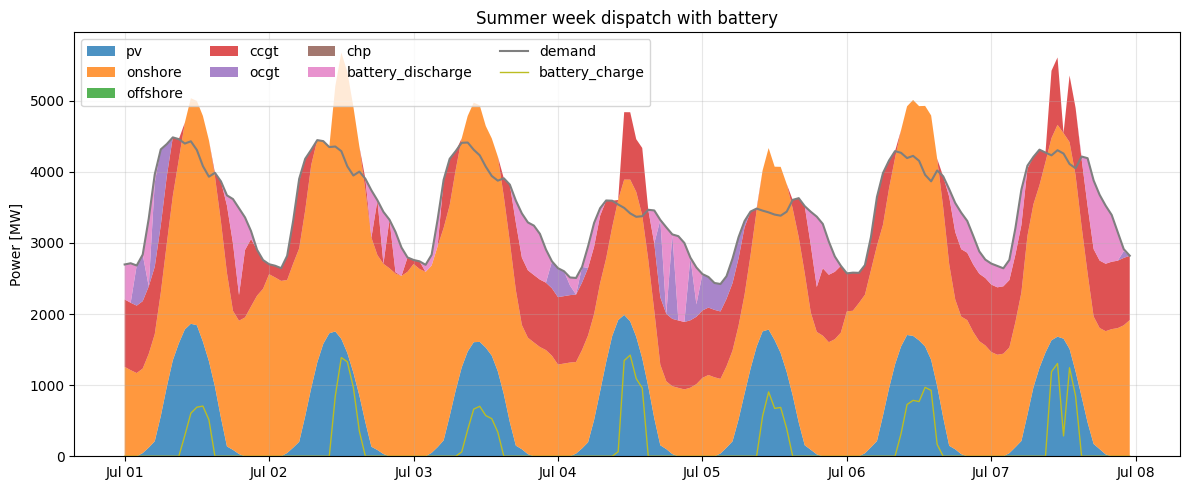

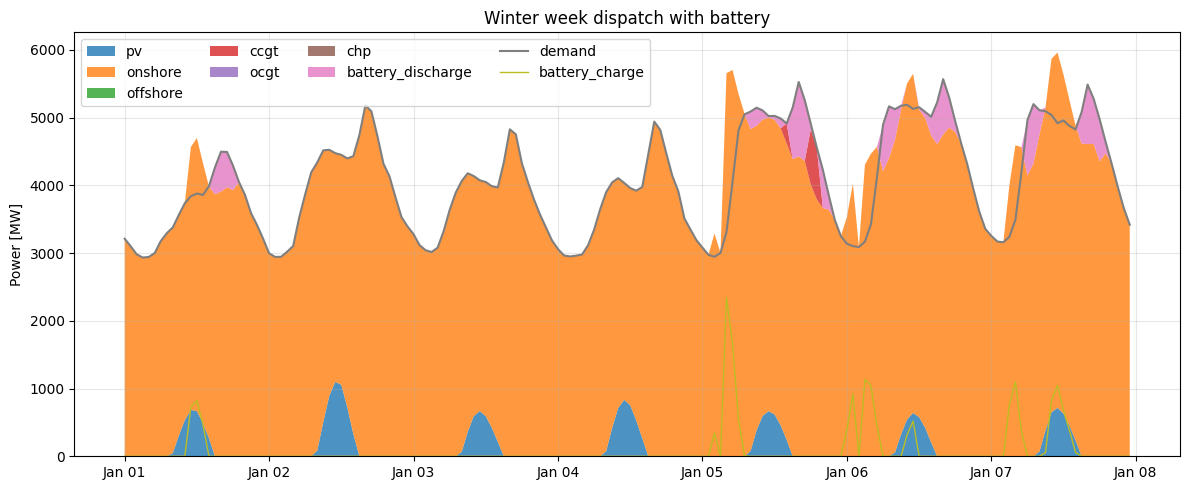

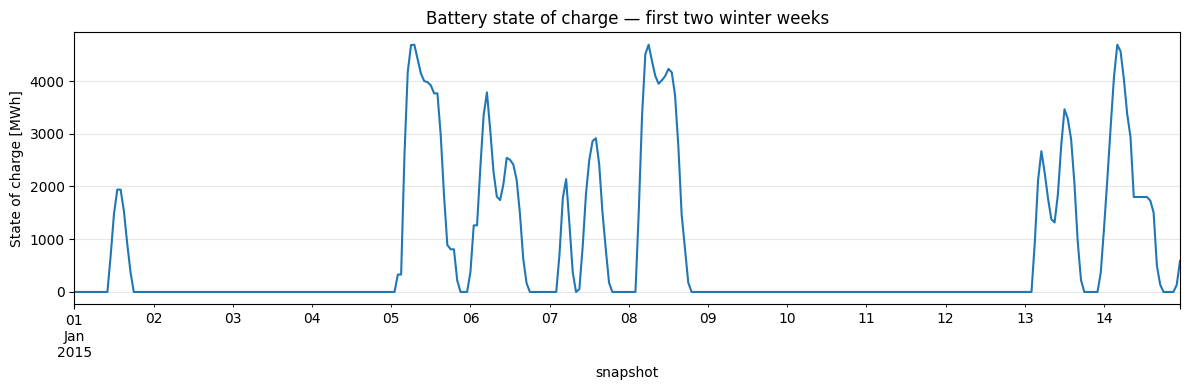

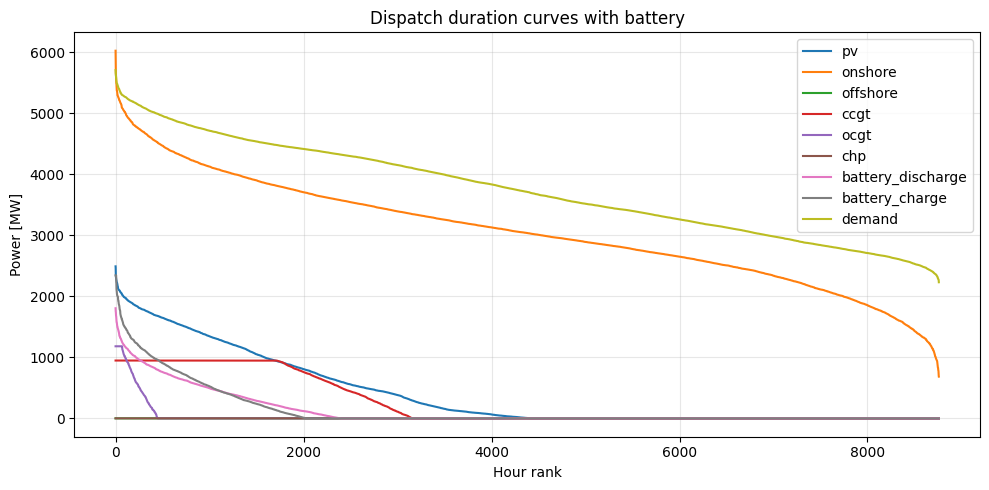

In [30]:

# Part C dispatch and storage plots

dispatch_c = n_c.generators_t.p[gen_order].copy()
dispatch_c["battery_discharge"] = n_c.storage_units_t.p[storage_name].clip(lower=0)
dispatch_c["battery_charge"] = n_c.storage_units_t.p[storage_name].clip(upper=0)
dispatch_c["demand"] = work_df["demand_mw"]

for title, start, end in [
    ("Summer week dispatch with battery", "2015-07-01", "2015-07-07 23:00"),
    ("Winter week dispatch with battery", "2015-01-01", "2015-01-07 23:00"),
]:
    week = dispatch_c.loc[start:end]
    x = week.index

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.stackplot(
        x,
        week["pv"],
        week["onshore"],
        week["offshore"],
        week["ccgt"],
        week["ocgt"],
        week["chp"],
        week["battery_discharge"],
        labels=["pv", "onshore", "offshore", "ccgt", "ocgt", "chp", "battery_discharge"],
        alpha=0.8,
    )
    ax.plot(x, week["demand"], linewidth=1.5, label="demand")
    ax.plot(x, -week["battery_charge"], linewidth=1.0, label="battery_charge")
    ax.set_title(title)
    ax.set_ylabel("Power [MW]")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.legend(loc="upper left", ncol=4)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

soc = n_c.storage_units_t.state_of_charge[storage_name]
fig, ax = plt.subplots(figsize=(12, 4))
soc.loc["2015-01-01":"2015-01-14 23:00"].plot(ax=ax)
ax.set_title("Battery state of charge — first two winter weeks")
ax.set_ylabel("State of charge [MWh]")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


duration_c = pd.DataFrame({
    "pv": dispatch_c["pv"].sort_values(ascending=False).values,
    "onshore": dispatch_c["onshore"].sort_values(ascending=False).values,
    "offshore": dispatch_c["offshore"].sort_values(ascending=False).values,
    "ccgt": dispatch_c["ccgt"].sort_values(ascending=False).values,
    "ocgt": dispatch_c["ocgt"].sort_values(ascending=False).values,
    "chp": dispatch_c["chp"].sort_values(ascending=False).values,
    "battery_discharge": dispatch_c["battery_discharge"].sort_values(ascending=False).values,
    "battery_charge": (-dispatch_c["battery_charge"]).sort_values(ascending=False).values,
    "demand": dispatch_c["demand"].sort_values(ascending=False).values,
})

fig, ax = plt.subplots(figsize=(10, 5))
duration_c.plot(ax=ax)
ax.set_title("Dispatch duration curves with battery")
ax.set_xlabel("Hour rank")
ax.set_ylabel("Power [MW]")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Part D

PyPSA native geo plotting failed, using robust Cartopy fallback.
Reason: Cannot interpret '<StringDtype(storage='python', na_value=nan)>' as a data type


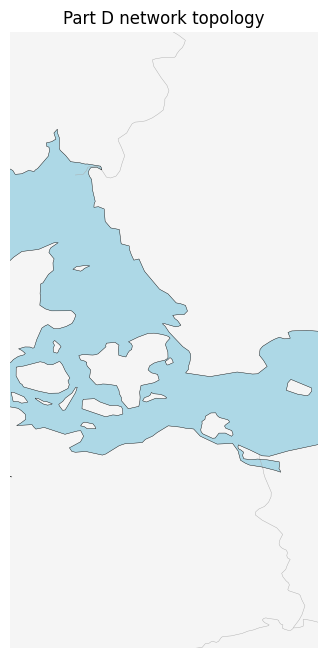

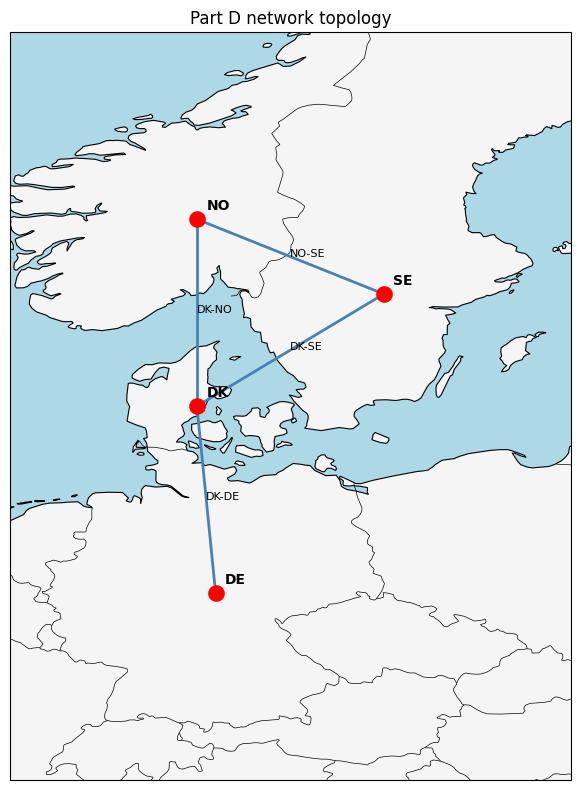

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ------------------------------------------------------------
# Helper: convert pandas StringDtype -> plain object dtype
# ------------------------------------------------------------
def _coerce_stringdtype_to_object(df):
    df = df.copy()

    for col in df.columns:
        if str(df[col].dtype).startswith("string"):
            df[col] = df[col].astype(object)

    if str(df.index.dtype).startswith("string"):
        df.index = df.index.astype(object)

    return df

# ------------------------------------------------------------
# Apply dtype cleanup to PyPSA static tables that plotting may touch
# ------------------------------------------------------------
for attr in ["buses", "lines", "links", "transformers", "carriers"]:
    if hasattr(n_d, attr):
        try:
            setattr(n_d, attr, _coerce_stringdtype_to_object(getattr(n_d, attr)))
        except Exception:
            pass

# ------------------------------------------------------------
# Try the correct native PyPSA geo plot first
# ------------------------------------------------------------
try:
    fig, ax = plt.subplots(
        figsize=(8, 8),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    n_d.plot.map(
        ax=ax,
        geomap=True,
        geomap_resolution="50m",
        geomap_color=True,
        bus_size=0.03,
        bus_color="red",
        line_width=2.0,
        line_color="steelblue",
        title="Part D network topology"
    )

    for bus, row in n_d.buses.iterrows():
        ax.text(
            float(row["x"]) + 0.25,
            float(row["y"]) + 0.25,
            str(bus),
            transform=ccrs.PlateCarree(),
            fontsize=10,
            weight="bold"
        )

    plt.tight_layout()
    plt.show()

except Exception as e:
    print("PyPSA native geo plotting failed, using robust Cartopy fallback.")
    print(f"Reason: {e}")

    # --------------------------------------------------------
    # Robust fallback: geographic map with Cartopy + manual draw
    # This still gives you a true geo map for the report
    # --------------------------------------------------------
    fig, ax = plt.subplots(
        figsize=(8, 8),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    ax.add_feature(cfeature.LAND, facecolor="whitesmoke")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # set map extent around the study region
    xmin = n_d.buses["x"].min() - 5
    xmax = n_d.buses["x"].max() + 5
    ymin = n_d.buses["y"].min() - 5
    ymax = n_d.buses["y"].max() + 5
    ax.set_extent([xmin, xmax, ymin, ymax], crs=ccrs.PlateCarree())

    # draw lines
    for line_name, line in n_d.lines.iterrows():
        x0 = float(n_d.buses.loc[line["bus0"], "x"])
        y0 = float(n_d.buses.loc[line["bus0"], "y"])
        x1 = float(n_d.buses.loc[line["bus1"], "x"])
        y1 = float(n_d.buses.loc[line["bus1"], "y"])

        ax.plot(
            [x0, x1], [y0, y1],
            transform=ccrs.PlateCarree(),
            linewidth=2.0,
            color="steelblue"
        )

        xm = 0.5 * (x0 + x1)
        ym = 0.5 * (y0 + y1)
        ax.text(
            xm, ym, str(line_name),
            transform=ccrs.PlateCarree(),
            fontsize=8
        )

    # draw buses
    ax.scatter(
        n_d.buses["x"].astype(float),
        n_d.buses["y"].astype(float),
        transform=ccrs.PlateCarree(),
        s=120,
        color="red",
        zorder=5
    )

    for bus, row in n_d.buses.iterrows():
        ax.text(
            float(row["x"]) + 0.25,
            float(row["y"]) + 0.25,
            str(bus),
            transform=ccrs.PlateCarree(),
            fontsize=10,
            weight="bold"
        )

    ax.set_title("Part D network topology")
    plt.tight_layout()
    plt.show()

In [36]:
# ============================================================
# PART D — BLOCK 2
# Add nodal loads + generators and optimise the 4-node network
# ============================================================

import pandas as pd
import pypsa

# ------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------
if "n_d" not in globals():
    raise NameError("Run Block D.1 first so that the topology network 'n_d' exists.")

if "tech_costs" not in globals():
    raise NameError("The notebook variable 'tech_costs' is not defined.")

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def load_country_table(path, sep=";"):
    df = pd.read_csv(path, sep=sep)
    df["utc_time"] = pd.to_datetime(df["utc_time"], utc=True).dt.tz_localize(None)
    df = df.set_index("utc_time")
    return df

def pick_country_column(df, aliases):
    for col in aliases:
        if col in df.columns:
            return col
    raise KeyError(f"None of {aliases} found in columns: {list(df.columns)}")

def align_series_to_snapshots(series, snapshots, name):
    s = series.copy().reindex(snapshots)
    if s.isna().any():
        missing = int(s.isna().sum())
        raise ValueError(f"{name} is missing {missing} aligned hours.")
    return s

# ------------------------------------------------------------
# Country-code aliases
# ------------------------------------------------------------
country_aliases = {
    "DK": ["DNK", "DK"],
    "NO": ["NOR", "NO"],
    "SE": ["SWE", "SE"],
    "GB": ["GBR", "GB"],
}

# ------------------------------------------------------------
# Load hourly data
# ------------------------------------------------------------
demand_all   = load_country_table("data/electricity_demand.csv")
onshore_all  = load_country_table("data/onshore_wind_capacity_factor_raw.csv")
offshore_all = load_country_table("data/offshore_wind_capacity_factor_raw.csv")
pv_all       = load_country_table("data/pv_capacity_factor_raw.csv")

# ------------------------------------------------------------
# Start from the Block D.1 topology
# ------------------------------------------------------------
n_d2 = n_d.copy()
snapshots = pd.DatetimeIndex(n_d2.snapshots)

# ------------------------------------------------------------
# Add loads
# ------------------------------------------------------------
for bus in ["DK", "NO", "SE", "GB"]:
    demand_col = pick_country_column(demand_all, country_aliases[bus])
    demand_series = align_series_to_snapshots(
        demand_all[demand_col],
        snapshots,
        f"demand_{bus}"
    )

    n_d2.add(
        "Load",
        f"load_{bus}",
        bus=bus,
        p_set=demand_series,
    )

# ------------------------------------------------------------
# Add generators at each node
# Uses the cost structure already defined in this notebook:
# tech_costs["capital_cost_eur_per_mw_year"]
# tech_costs["marginal_cost_eur_per_mwh"]
# ------------------------------------------------------------
for bus in ["DK", "NO", "SE", "GB"]:
    onshore_col = pick_country_column(onshore_all, country_aliases[bus])
    offshore_col = pick_country_column(offshore_all, country_aliases[bus])
    pv_col = pick_country_column(pv_all, country_aliases[bus])

    onshore_cf = align_series_to_snapshots(onshore_all[onshore_col], snapshots, f"onshore_cf_{bus}")
    offshore_cf = align_series_to_snapshots(offshore_all[offshore_col], snapshots, f"offshore_cf_{bus}")
    pv_cf = align_series_to_snapshots(pv_all[pv_col], snapshots, f"pv_cf_{bus}")

    # Variable renewables
    n_d2.add(
        "Generator",
        f"pv_{bus}",
        bus=bus,
        carrier="pv",
        p_nom_extendable=True,
        p_max_pu=pv_cf,
        capital_cost=float(tech_costs.loc["pv", "capital_cost_eur_per_mw_year"]),
        marginal_cost=float(tech_costs.loc["pv", "marginal_cost_eur_per_mwh"]),
    )

    n_d2.add(
        "Generator",
        f"onshore_{bus}",
        bus=bus,
        carrier="onshore",
        p_nom_extendable=True,
        p_max_pu=onshore_cf,
        capital_cost=float(tech_costs.loc["onshore", "capital_cost_eur_per_mw_year"]),
        marginal_cost=float(tech_costs.loc["onshore", "marginal_cost_eur_per_mwh"]),
    )

    n_d2.add(
        "Generator",
        f"offshore_{bus}",
        bus=bus,
        carrier="offshore",
        p_nom_extendable=True,
        p_max_pu=offshore_cf,
        capital_cost=float(tech_costs.loc["offshore", "capital_cost_eur_per_mw_year"]),
        marginal_cost=float(tech_costs.loc["offshore", "marginal_cost_eur_per_mwh"]),
    )

    # Dispatchable thermal
    for tech in ["ccgt", "ocgt", "chp"]:
        n_d2.add(
            "Generator",
            f"{tech}_{bus}",
            bus=bus,
            carrier=tech,
            p_nom_extendable=True,
            capital_cost=float(tech_costs.loc[tech, "capital_cost_eur_per_mw_year"]),
            marginal_cost=float(tech_costs.loc[tech, "marginal_cost_eur_per_mwh"]),
        )

# ------------------------------------------------------------
# Optimise
# ------------------------------------------------------------
status_d2, condition_d2 = n_d2.optimize(solver_name="highs")
print("Part D.2 status:", status_d2, condition_d2)

# ------------------------------------------------------------
# Core result tables
# ------------------------------------------------------------
capacity_d2 = (
    n_d2.generators[["bus", "carrier", "p_nom_opt"]]
    .groupby(["bus", "carrier"])["p_nom_opt"]
    .sum()
    .unstack(fill_value=0)
)

generation_d2 = (
    n_d2.generators_t.p.sum()
    .rename("generation_mwh")
    .to_frame()
    .join(n_d2.generators[["bus", "carrier"]])
    .groupby(["bus", "carrier"])["generation_mwh"]
    .sum()
    .unstack(fill_value=0)
)

line_flow_d2 = n_d2.lines_t.p0.copy()
line_loading_d2 = line_flow_d2.abs().divide(n_d2.lines["s_nom"], axis=1)

line_summary_d2 = pd.DataFrame({
    "s_nom_mw": n_d2.lines["s_nom"],
    "max_abs_flow_mw": line_flow_d2.abs().max(),
    "mean_abs_flow_mw": line_flow_d2.abs().mean(),
    "max_loading_pu": line_loading_d2.max(),
}).sort_values("max_loading_pu", ascending=False)

mean_nodal_price_d2 = n_d2.buses_t.marginal_price.mean().rename("mean_price_eur_per_mwh")

print("\n=== Optimised capacity by bus and technology [MW] ===")
display(capacity_d2.round(2))

print("\n=== Annual generation by bus and technology [MWh] ===")
display(generation_d2.round(2))

print("\n=== Line loading summary ===")
display(line_summary_d2.round(3))

print("\n=== Mean nodal prices [EUR/MWh] ===")
display(mean_nodal_price_d2.round(2))

Index(['load_GB'], dtype='str', name='name')
Index(['pv_GB'], dtype='str', name='name')
Index(['pv_GB', 'onshore_GB'], dtype='str', name='name')
Index(['pv_GB', 'onshore_GB', 'offshore_GB'], dtype='str', name='name')
Index(['pv_GB', 'onshore_GB', 'offshore_GB', 'ccgt_GB'], dtype='str', name='name')
Index(['pv_GB', 'onshore_GB', 'offshore_GB', 'ccgt_GB', 'ocgt_GB'], dtype='str', name='name')
Index(['pv_GB', 'onshore_GB', 'offshore_GB', 'ccgt_GB', 'ocgt_GB', 'chp_GB'], dtype='str', name='name')
C:\Users\Study\AppData\Local\Temp\ipykernel_15656\1795201299.py:146: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['DK', 'NO', 'SE', 'DE'], dtype='str', name='name')


ConsistencyError: The following generators have buses which are not defined. Add them using n.add() or run n.sanitize() to add them automatically. Components with undefined buses:
Index(['pv_GB', 'onshore_GB', 'offshore_GB', 'ccgt_GB', 'ocgt_GB', 'chp_GB'], dtype='str', name='name')


=== Part D.3: Annual balance by bus ===


,annual_generation_mwh,annual_demand_mwh,annual_net_import_mwh,generation_minus_demand_mwh
DK,3.858417e+07,3.281394e+07,-5770232.96,5770232.96
NO,1.317808e+08,1.286533e+08,-3127507.48,3127507.48
SE,1.311403e+08,1.359264e+08,4786071.86,-4786071.86
DE,5.011529e+08,5.052646e+08,4111668.59,-4111668.59



=== Part D.3: Technology generation by bus [MWh] ===


carrier,ccgt,chp,ocgt,offshore,onshore,pv
bus,,,,,,
DE,2.015160e+08,0.0,6592432.24,0.00,1.717106e+08,1.213339e+08
DK,5.478587e+06,0.0,612641.22,0.00,2.751486e+07,4.978088e+06
NO,1.511092e+07,0.0,2179524.14,19040646.93,9.544968e+07,0.000000e+00
SE,4.504023e+07,0.0,2234003.03,2055816.54,6.469830e+07,1.711197e+07



=== Part D.3: Technology generation shares by bus [%] ===


...

,mean_price_eur_per_mwh,std_price_eur_per_mwh,min_price_eur_per_mwh,max_price_eur_per_mwh
name,,,,
DE,51.21,470.37,-0.0,44004.00
SE,49.86,345.27,-0.0,28459.75
DK,45.31,273.10,-0.0,15240.67
NO,38.63,349.15,4.0,28826.04



=== Part D.3: Most congested line/hour ===
Most congested line: DK-NO
Most congested hour: 2015-01-01 04:00:00
Maximum loading: 1.000 p.u.

=== Part D.3: Nodal balance at most congested hour ===


,generation_mw,demand_mw,net_import_mw,nodal_price_eur_per_mwh,generation_minus_demand_mw
DK,7641.54,2941.54,-4700.0,4.00,4700.0
NO,12003.00,14903.00,2900.0,4.00,-2900.0
SE,15070.00,14370.00,-700.0,4.00,700.0
DE,37747.00,40247.00,2500.0,57.13,-2500.0



=== Part D.3: Line flows at most congested hour ===


,bus0,bus1,flow_p0_mw,loading_pu
name,,,,
DK-NO,DK,NO,1700.0,1.00
DK-DE,DK,DE,2500.0,1.00
NO-SE,NO,SE,-1200.0,1.00
DK-SE,DK,SE,500.0,0.25


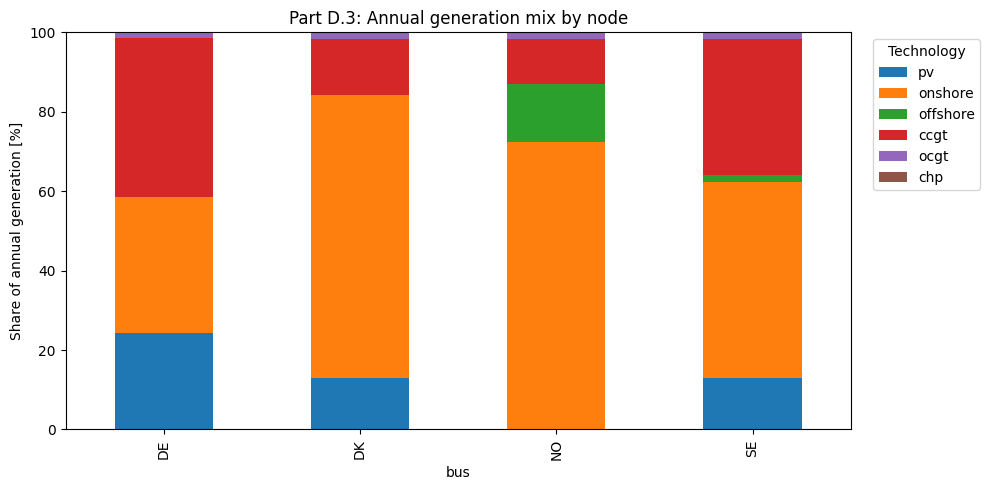

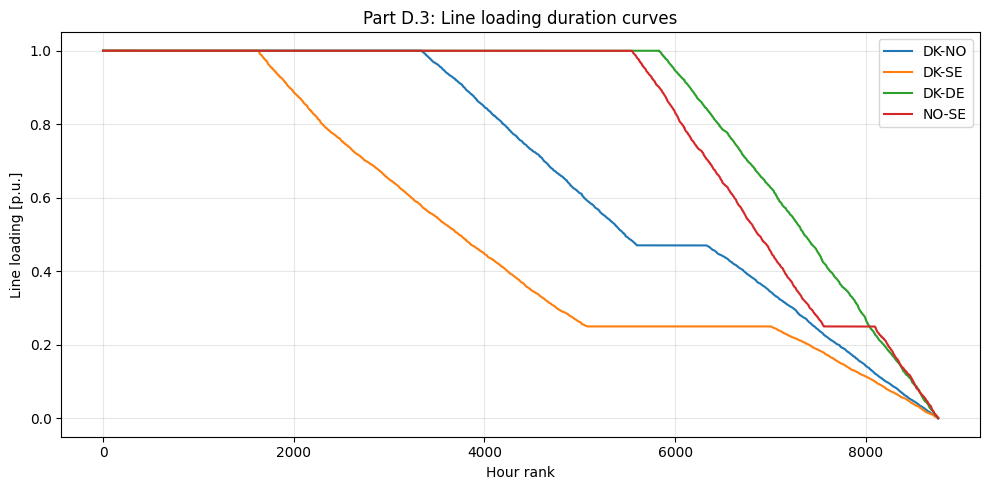

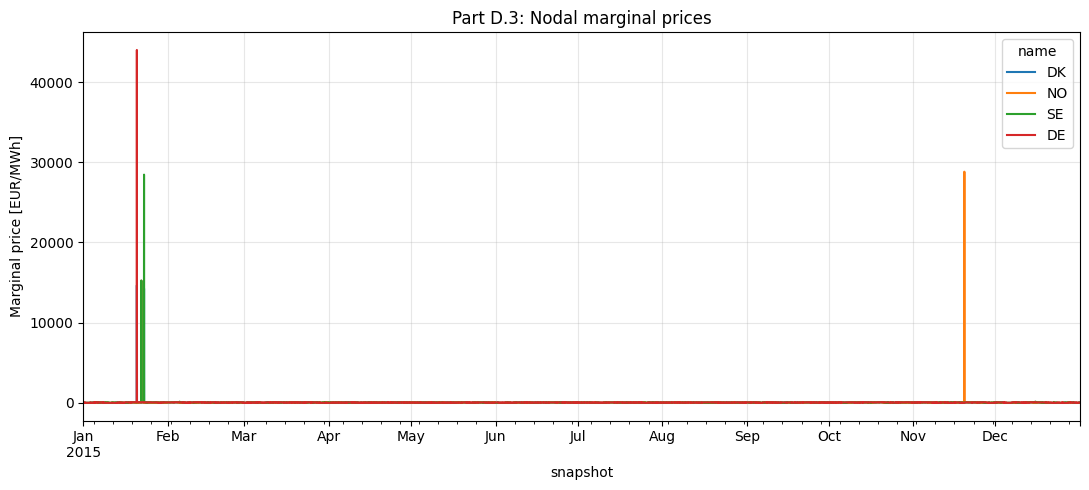

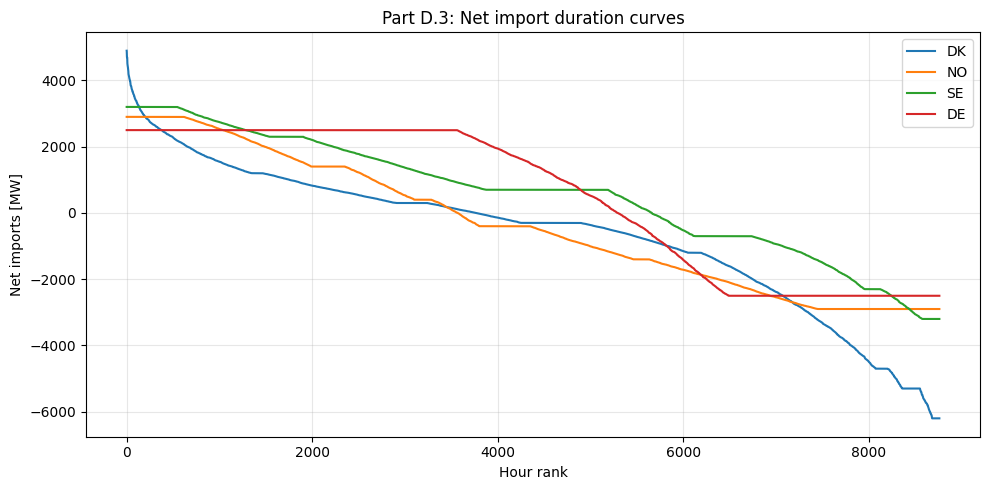

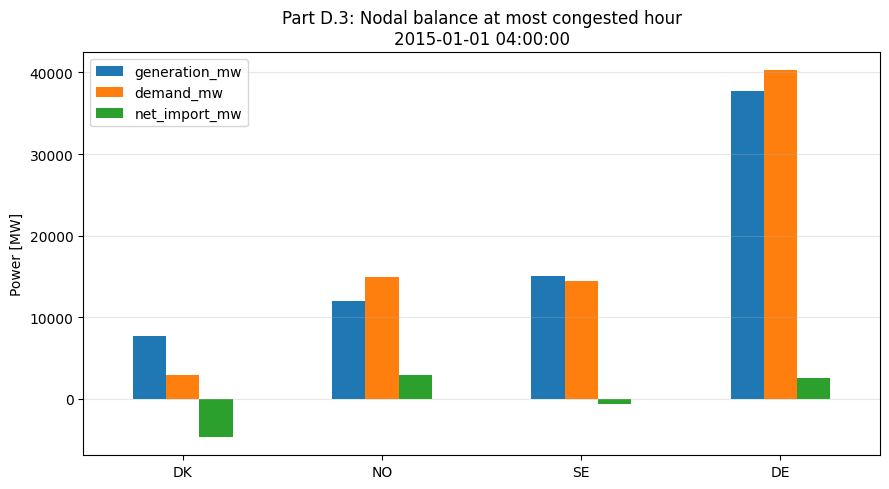


Part D shows how the meshed 4-node system uses the fixed HVAC interconnectors to share generation across neighbouring countries.
The most stressed interconnector is DK-NO, which reaches a maximum loading of 1.000 p.u.
and exceeds 90% loading for 3789 hours.

On an annual basis, the largest net importer is SE, while the largest net exporter is DK.
This indicates that the fixed transmission capacities materially affect the spatial allocation of generation and the resulting power exchanges.

Average nodal prices are highest in DE (51.21 EUR/MWh)
and lowest in NO (38.63 EUR/MWh),
which is consistent with transmission constraints and differences in local generation availability.

The most congested system state occurs at 2015-01-01 04:00:00, when line DK-NO
reaches 1.000 p.u. loading. This snapshot is a useful reference for the Part E hand calculation,
where the PTDF matrix and nodal imbalances for the first analysed time step are compared against the modelled line flows.



In [35]:
# ============================================================
# PART D — BLOCK 3
# Analyse meshed-network results: dispatch, flows, congestion,
# imports/exports, and nodal prices
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Preconditions
# ------------------------------------------------------------
if "n_d2" not in globals():
    raise NameError("Run Block D.2 first so that the solved network 'n_d2' exists.")

# ------------------------------------------------------------
# Basic sets
# ------------------------------------------------------------
buses = list(n_d2.buses.index)
lines = list(n_d2.lines.index)
tech_order = ["pv", "onshore", "offshore", "ccgt", "ocgt", "chp"]

# ------------------------------------------------------------
# 1) Dispatch by bus and by technology
# ------------------------------------------------------------
dispatch_gen = n_d2.generators_t.p.copy()  # MW, hourly

gen_meta = n_d2.generators[["bus", "carrier"]].copy()

dispatch_by_bus = {}
dispatch_by_tech = {}
dispatch_by_bus_tech = {}

for bus in buses:
    gens_bus = gen_meta.index[gen_meta["bus"] == bus]
    dispatch_by_bus[bus] = dispatch_gen[gens_bus].sum(axis=1)

dispatch_by_bus = pd.DataFrame(dispatch_by_bus)

for tech in tech_order:
    if tech in gen_meta["carrier"].values:
        gens_tech = gen_meta.index[gen_meta["carrier"] == tech]
        dispatch_by_tech[tech] = dispatch_gen[gens_tech].sum(axis=1)

dispatch_by_tech = pd.DataFrame(dispatch_by_tech)
dispatch_by_tech = dispatch_by_tech.reindex(
    columns=[t for t in tech_order if t in dispatch_by_tech.columns]
)
for bus in buses:
    dispatch_by_bus_tech[bus] = {}
    for tech in tech_order:
        gens = gen_meta.index[(gen_meta["bus"] == bus) & (gen_meta["carrier"] == tech)]
        if len(gens) > 0:
            dispatch_by_bus_tech[bus][tech] = dispatch_gen[gens].sum(axis=1)

# ------------------------------------------------------------
# 2) Demand by bus
# ------------------------------------------------------------
load_ts = n_d2.loads_t.p_set.copy()
load_meta = n_d2.loads[["bus"]].copy()

demand_by_bus = {}
for bus in buses:
    loads_bus = load_meta.index[load_meta["bus"] == bus]
    demand_by_bus[bus] = load_ts[loads_bus].sum(axis=1)

demand_by_bus = pd.DataFrame(demand_by_bus)

# ------------------------------------------------------------
# 3) Line flows and loading
# Convention:
#   lines_t.p0 > 0 means flow from bus0 to bus1
# ------------------------------------------------------------
line_flow_p0 = n_d2.lines_t.p0.copy()  # MW
line_loading = line_flow_p0.abs().divide(n_d2.lines["s_nom"], axis=1)

line_summary_d3 = pd.DataFrame({
    "bus0": n_d2.lines["bus0"],
    "bus1": n_d2.lines["bus1"],
    "s_nom_mw": n_d2.lines["s_nom"],
    "max_abs_flow_mw": line_flow_p0.abs().max(),
    "mean_abs_flow_mw": line_flow_p0.abs().mean(),
    "max_loading_pu": line_loading.max(),
    "mean_loading_pu": line_loading.mean(),
    "hours_above_70pct": (line_loading >= 0.70).sum(),
    "hours_above_90pct": (line_loading >= 0.90).sum(),
    "hours_congested_99pct": (line_loading >= 0.99).sum(),
}).sort_values("max_loading_pu", ascending=False)

# ------------------------------------------------------------
# 4) Net imports/exports by bus
# Positive value = net imports into the bus
# ------------------------------------------------------------
net_import_by_bus = pd.DataFrame(0.0, index=n_d2.snapshots, columns=buses)

for line_name, row in n_d2.lines.iterrows():
    b0 = row["bus0"]
    b1 = row["bus1"]

    # p0 > 0 means export from bus0 to bus1
    net_import_by_bus[b0] += -line_flow_p0[line_name]
    net_import_by_bus[b1] +=  line_flow_p0[line_name]

annual_net_import_mwh = net_import_by_bus.sum(axis=0).rename("annual_net_import_mwh")
annual_import_export_summary = pd.DataFrame({
    "annual_net_import_mwh": annual_net_import_mwh,
    "mean_net_import_mw": net_import_by_bus.mean(axis=0),
    "max_import_mw": net_import_by_bus.max(axis=0),
    "max_export_mw": net_import_by_bus.min(axis=0),  # negative means export
}).sort_index()

# ------------------------------------------------------------
# 5) Nodal prices
# ------------------------------------------------------------
nodal_prices = n_d2.buses_t.marginal_price.copy()

price_summary_d3 = pd.DataFrame({
    "mean_price_eur_per_mwh": nodal_prices.mean(),
    "std_price_eur_per_mwh": nodal_prices.std(),
    "min_price_eur_per_mwh": nodal_prices.min(),
    "max_price_eur_per_mwh": nodal_prices.max(),
}).sort_values("mean_price_eur_per_mwh", ascending=False)

# ------------------------------------------------------------
# 6) System-level annual summaries
# ------------------------------------------------------------
annual_generation_bus = dispatch_by_bus.sum(axis=0).rename("annual_generation_mwh")
annual_demand_bus = demand_by_bus.sum(axis=0).rename("annual_demand_mwh")

annual_balance = pd.concat(
    [annual_generation_bus, annual_demand_bus, annual_net_import_mwh],
    axis=1
)

annual_balance["generation_minus_demand_mwh"] = (
    annual_balance["annual_generation_mwh"] - annual_balance["annual_demand_mwh"]
)

# technology mix by bus
generation_by_bus_tech_d3 = (
    n_d2.generators_t.p.sum()
    .rename("generation_mwh")
    .to_frame()
    .join(n_d2.generators[["bus", "carrier"]])
    .groupby(["bus", "carrier"])["generation_mwh"]
    .sum()
    .unstack(fill_value=0)
)

generation_share_by_bus_tech_d3 = generation_by_bus_tech_d3.div(
    generation_by_bus_tech_d3.sum(axis=1), axis=0
) * 100

# ------------------------------------------------------------
# 7) Most congested hour / line
# ------------------------------------------------------------
most_congested_line = line_loading.max().idxmax()
most_congested_hour = line_loading[most_congested_line].idxmax()
max_loading_value = line_loading.loc[most_congested_hour, most_congested_line]

snapshot_balance = pd.DataFrame({
    "generation_mw": dispatch_by_bus.loc[most_congested_hour],
    "demand_mw": demand_by_bus.loc[most_congested_hour],
    "net_import_mw": net_import_by_bus.loc[most_congested_hour],
    "nodal_price_eur_per_mwh": nodal_prices.loc[most_congested_hour],
})
snapshot_balance["generation_minus_demand_mw"] = (
    snapshot_balance["generation_mw"] - snapshot_balance["demand_mw"]
)

snapshot_line_flows = pd.DataFrame({
    "bus0": n_d2.lines["bus0"],
    "bus1": n_d2.lines["bus1"],
    "flow_p0_mw": line_flow_p0.loc[most_congested_hour],
    "loading_pu": line_loading.loc[most_congested_hour],
}).sort_values("loading_pu", ascending=False)

# ------------------------------------------------------------
# 8) Display tables
# ------------------------------------------------------------
print("\n=== Part D.3: Annual balance by bus ===")
display(annual_balance.round(2))

print("\n=== Part D.3: Technology generation by bus [MWh] ===")
display(generation_by_bus_tech_d3.round(2))

print("\n=== Part D.3: Technology generation shares by bus [%] ===")
display(generation_share_by_bus_tech_d3.round(2))

print("\n=== Part D.3: Interconnector loading summary ===")
display(line_summary_d3.round(3))

print("\n=== Part D.3: Annual import/export summary by bus ===")
display(annual_import_export_summary.round(2))

print("\n=== Part D.3: Nodal price summary ===")
display(price_summary_d3.round(2))

print("\n=== Part D.3: Most congested line/hour ===")
print(f"Most congested line: {most_congested_line}")
print(f"Most congested hour: {most_congested_hour}")
print(f"Maximum loading: {max_loading_value:.3f} p.u.")

print("\n=== Part D.3: Nodal balance at most congested hour ===")
display(snapshot_balance.round(2))

print("\n=== Part D.3: Line flows at most congested hour ===")
display(snapshot_line_flows.round(3))

# ------------------------------------------------------------
# 9) Plots
# ------------------------------------------------------------

# 9.1 Annual generation mix by bus
fig, ax = plt.subplots(figsize=(10, 5))
generation_share_by_bus_tech_d3.reindex(columns=[c for c in tech_order if c in generation_share_by_bus_tech_d3.columns]).plot(
    kind="bar",
    stacked=True,
    ax=ax
)
ax.set_ylabel("Share of annual generation [%]")
ax.set_title("Part D.3: Annual generation mix by node")
ax.legend(title="Technology", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 9.2 Line loading duration curves
fig, ax = plt.subplots(figsize=(10, 5))
for line in lines:
    sorted_loading = line_loading[line].sort_values(ascending=False).reset_index(drop=True)
    ax.plot(sorted_loading, label=line)
ax.set_ylabel("Line loading [p.u.]")
ax.set_xlabel("Hour rank")
ax.set_title("Part D.3: Line loading duration curves")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# 9.3 Nodal price time series
fig, ax = plt.subplots(figsize=(11, 5))
nodal_prices.plot(ax=ax)
ax.set_ylabel("Marginal price [EUR/MWh]")
ax.set_title("Part D.3: Nodal marginal prices")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 9.4 Net import duration curves
fig, ax = plt.subplots(figsize=(10, 5))
for bus in buses:
    sorted_import = net_import_by_bus[bus].sort_values(ascending=False).reset_index(drop=True)
    ax.plot(sorted_import, label=bus)
ax.set_ylabel("Net imports [MW]")
ax.set_xlabel("Hour rank")
ax.set_title("Part D.3: Net import duration curves")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# 9.5 Dispatch and demand at most congested hour
fig, ax = plt.subplots(figsize=(9, 5))
snapshot_balance[["generation_mw", "demand_mw", "net_import_mw"]].plot(
    kind="bar",
    ax=ax
)
ax.set_ylabel("Power [MW]")
ax.set_title(f"Part D.3: Nodal balance at most congested hour\n{most_congested_hour}")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10) Auto-generated discussion text
# ------------------------------------------------------------
top_line = line_summary_d3.index[0]
top_importer = annual_import_export_summary["annual_net_import_mwh"].idxmax()
top_exporter = annual_import_export_summary["annual_net_import_mwh"].idxmin()
highest_price_bus = price_summary_d3.index[0]
lowest_price_bus = price_summary_d3.index[-1]

discussion_text = f"""
Part D shows how the meshed 4-node system uses the fixed HVAC interconnectors to share generation across neighbouring countries.
The most stressed interconnector is {top_line}, which reaches a maximum loading of {line_summary_d3.loc[top_line, 'max_loading_pu']:.3f} p.u.
and exceeds 90% loading for {int(line_summary_d3.loc[top_line, 'hours_above_90pct'])} hours.

On an annual basis, the largest net importer is {top_importer}, while the largest net exporter is {top_exporter}.
This indicates that the fixed transmission capacities materially affect the spatial allocation of generation and the resulting power exchanges.

Average nodal prices are highest in {highest_price_bus} ({price_summary_d3.loc[highest_price_bus, 'mean_price_eur_per_mwh']:.2f} EUR/MWh)
and lowest in {lowest_price_bus} ({price_summary_d3.loc[lowest_price_bus, 'mean_price_eur_per_mwh']:.2f} EUR/MWh),
which is consistent with transmission constraints and differences in local generation availability.

The most congested system state occurs at {most_congested_hour}, when line {most_congested_line}
reaches {max_loading_value:.3f} p.u. loading. This snapshot is a useful reference for the Part E hand calculation,
where the PTDF matrix and nodal imbalances for the first analysed time step are compared against the modelled line flows.
"""
print(discussion_text)